## # 연습문제 

### 1. 이전 분석 내용 가져오기

In [21]:
%%capture cap

# 자신의 실습 환경에 맞게 파일 경로 수정 
%run "./[LAB-08] PBT - EDAㅣ1-EDA 시작하기(연습문제) yeonju.ipynb"

### 2. 불러온 내용 확인 

In [22]:
print("종속변수:", target) 
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("연속형 : ", continuous_cols)
print("명목형 : ", nominal_cols)

display(df.head())
display(desc.head())
display(cat_desc.head())

종속변수: charges
종속변수 유형: 연속형
연속형 :  ['age', 'bmi', 'children']
명목형 :  ['sex', 'smoker', 'region']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000,0.006,similar,24.000,87.000,-9.000,0,0.000,0,0.000,0,0.000,0.055,symmetric,-1.244,platykurtic,none
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130,0.009,similar,8.410,47.315,13.675,9,0.007,0,0.000,9,0.007,0.284,symmetric,-0.053,platykurtic,none
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000,0.096,similar,2.000,5.000,-3.000,0,0.000,0,0.000,0,0.000,0.937,right tail,0.201,leptokurtic,log1p
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428,0.415,diff,11911.373,34524.778,-13120.716,139,0.104,0,0.000,139,0.104,1.515,right tail,1.604,leptokurtic,log1p


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


### 3. 라이브러리 참조하기 
    - 여기서는 사용 안함 

## #02. 종속변수의 단변량 분석 

### 1. 연속형 변수에 대한 분석 수행 

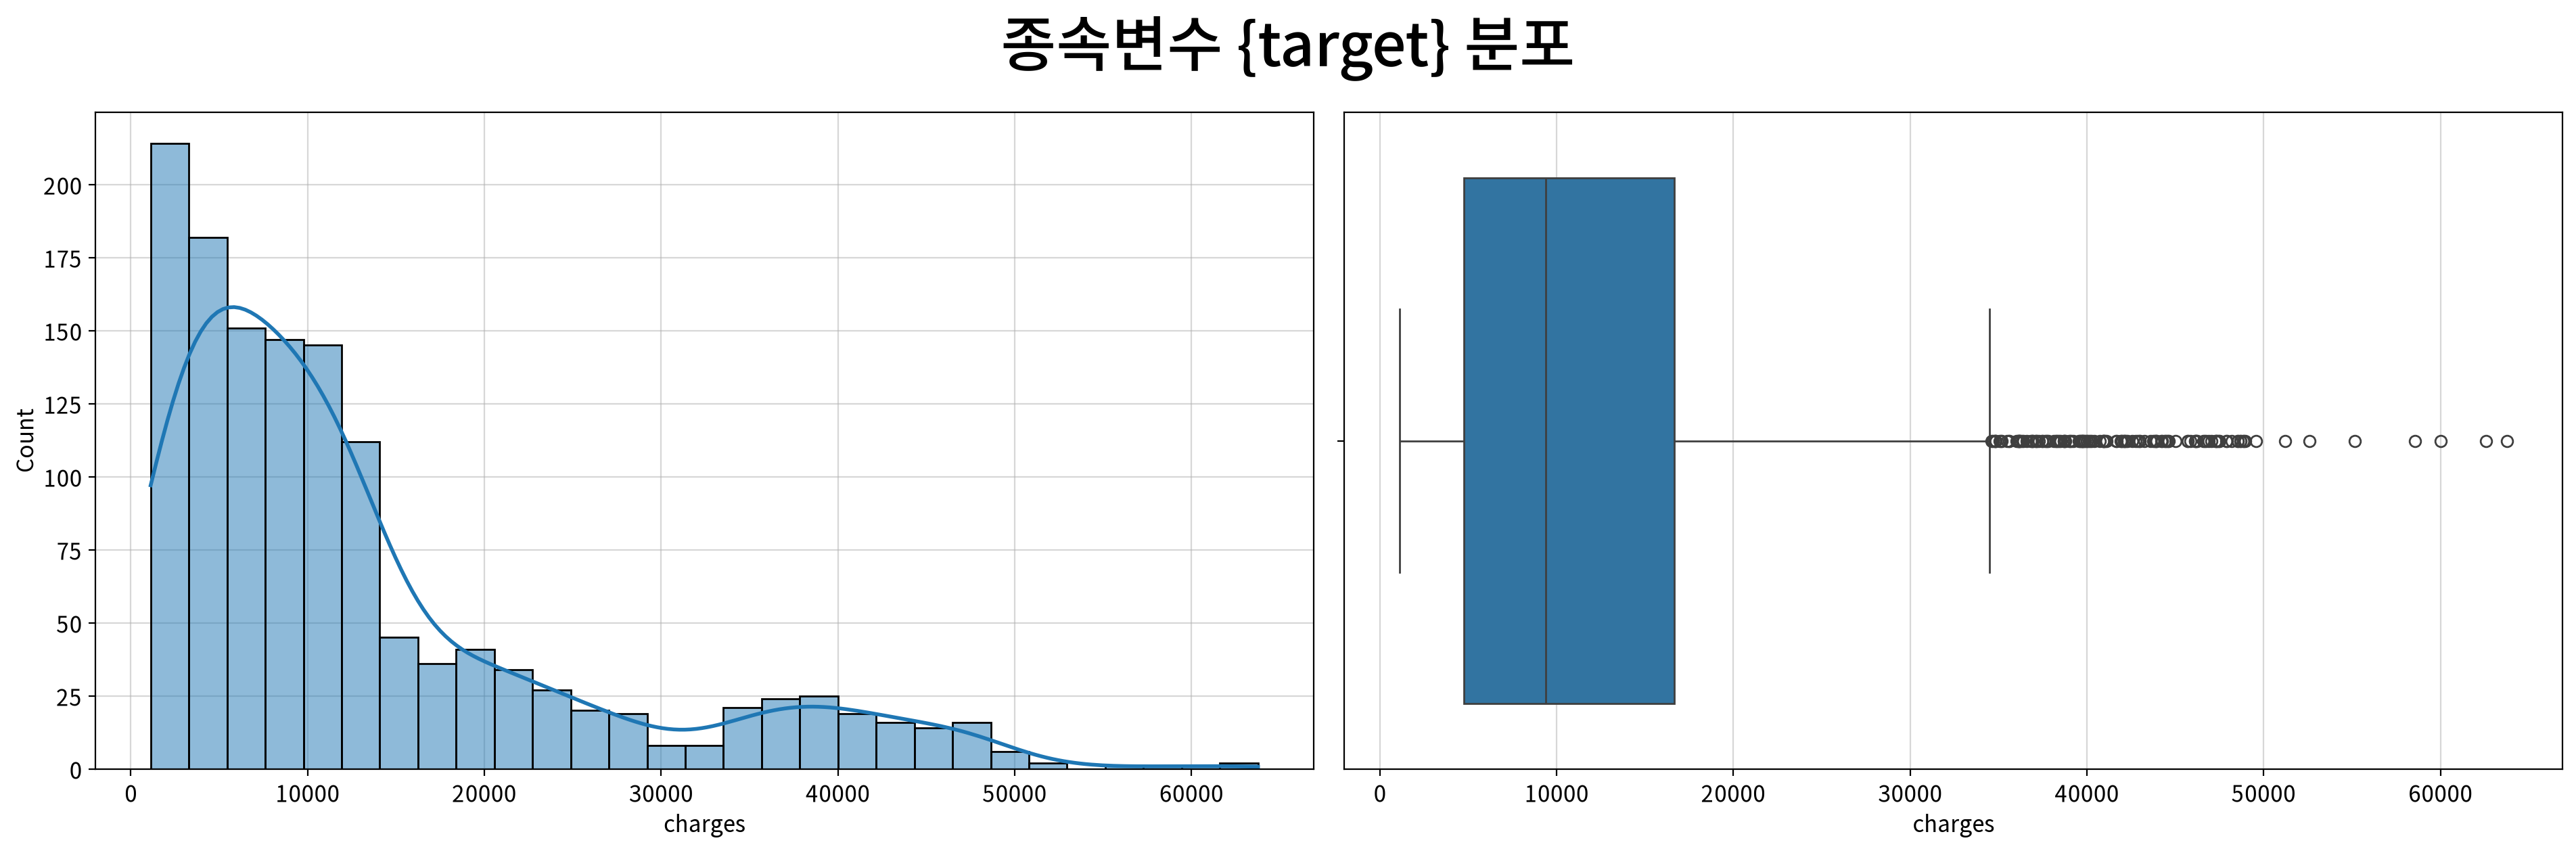

,charges
count,1337.000
mean,13279.121
std,12110.360
min,1121.874
25%,4746.344
50%,9386.161
75%,16657.717
max,63770.428
rel_diff,0.415
rdiff_flag,diff


In [23]:
# 1행 2열 서브플롯 구성 
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 X 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2, 
                       title="종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0]) # kde=True로 주면 그 히스토그램 위에 부드러운 곡선을 하나 더 겹쳐 그려줌
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
desc[desc.index == target].T

## #03. 독립변수의 단변량 분석 

### 1. 연속형 독립변수 

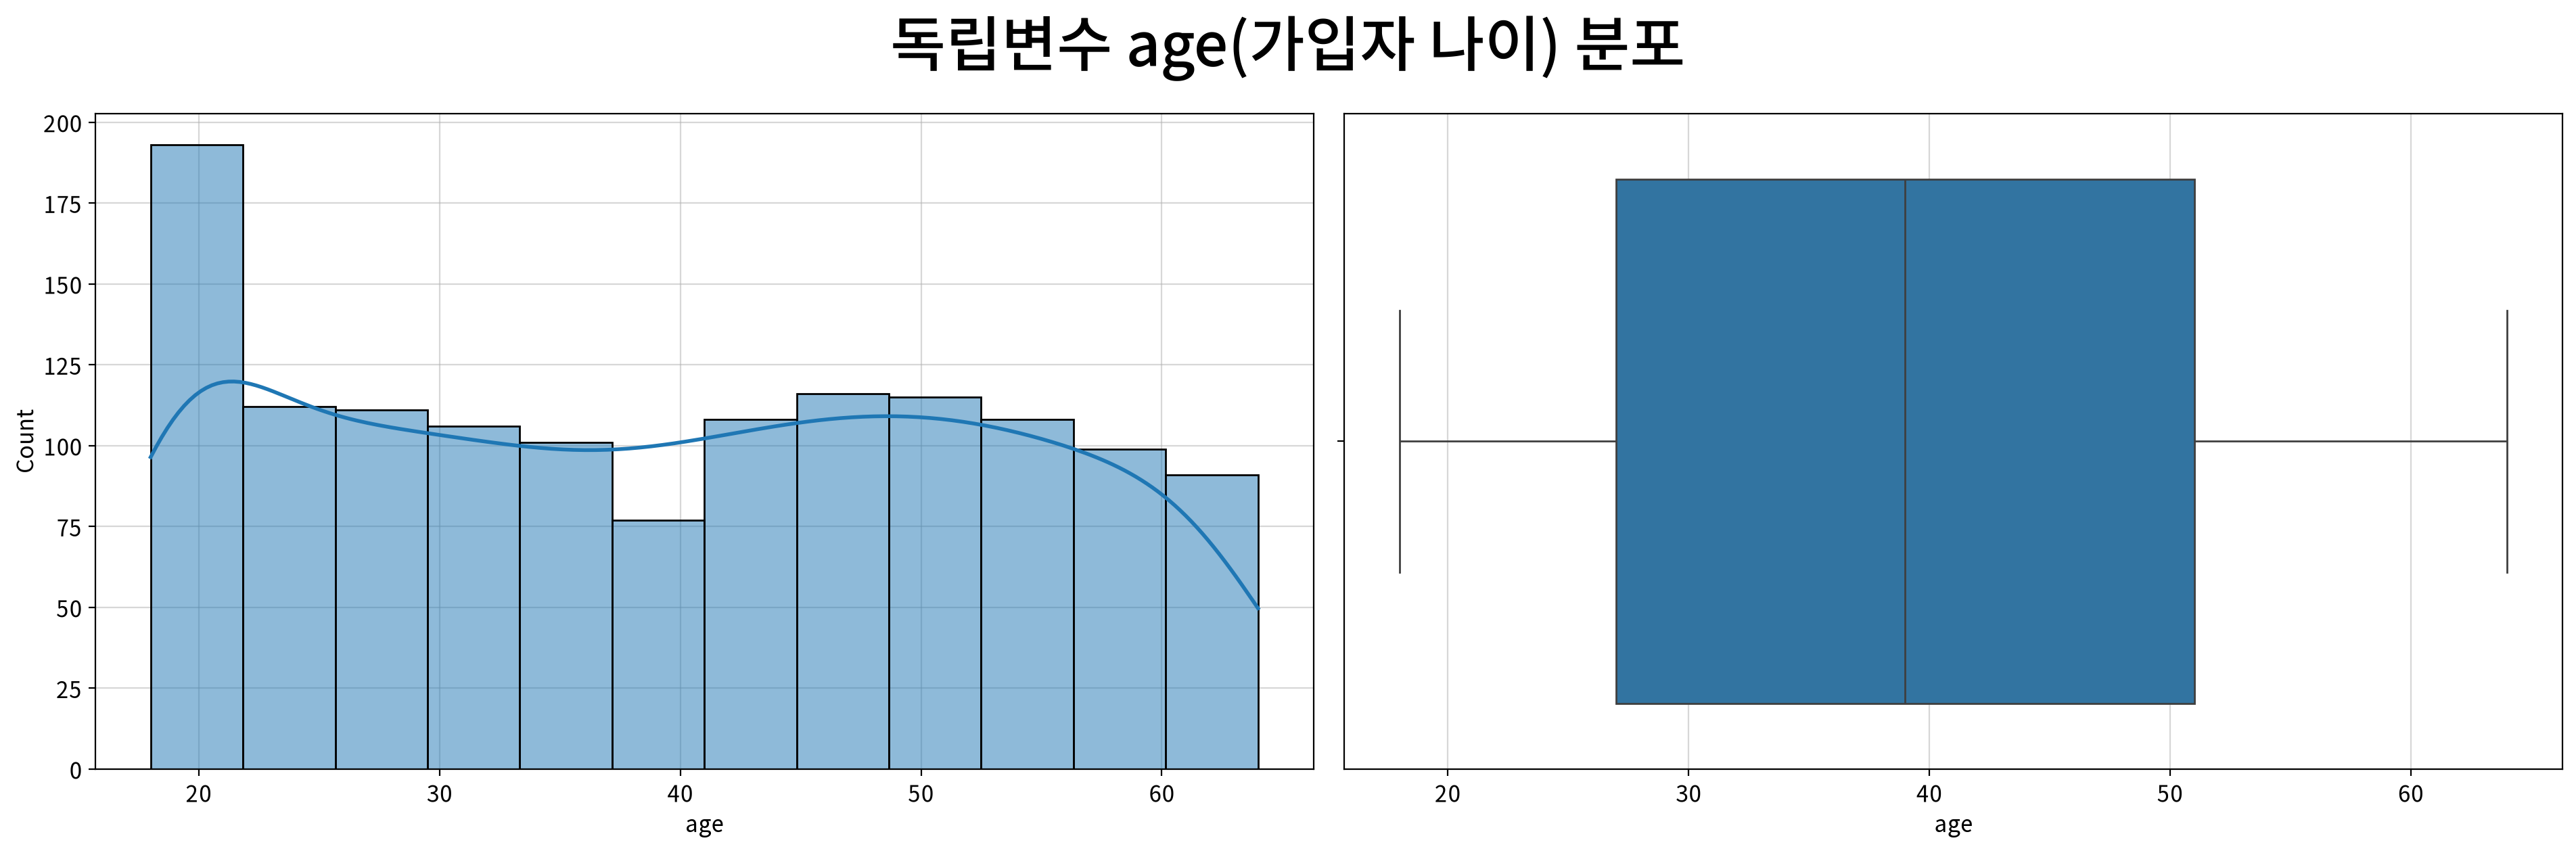

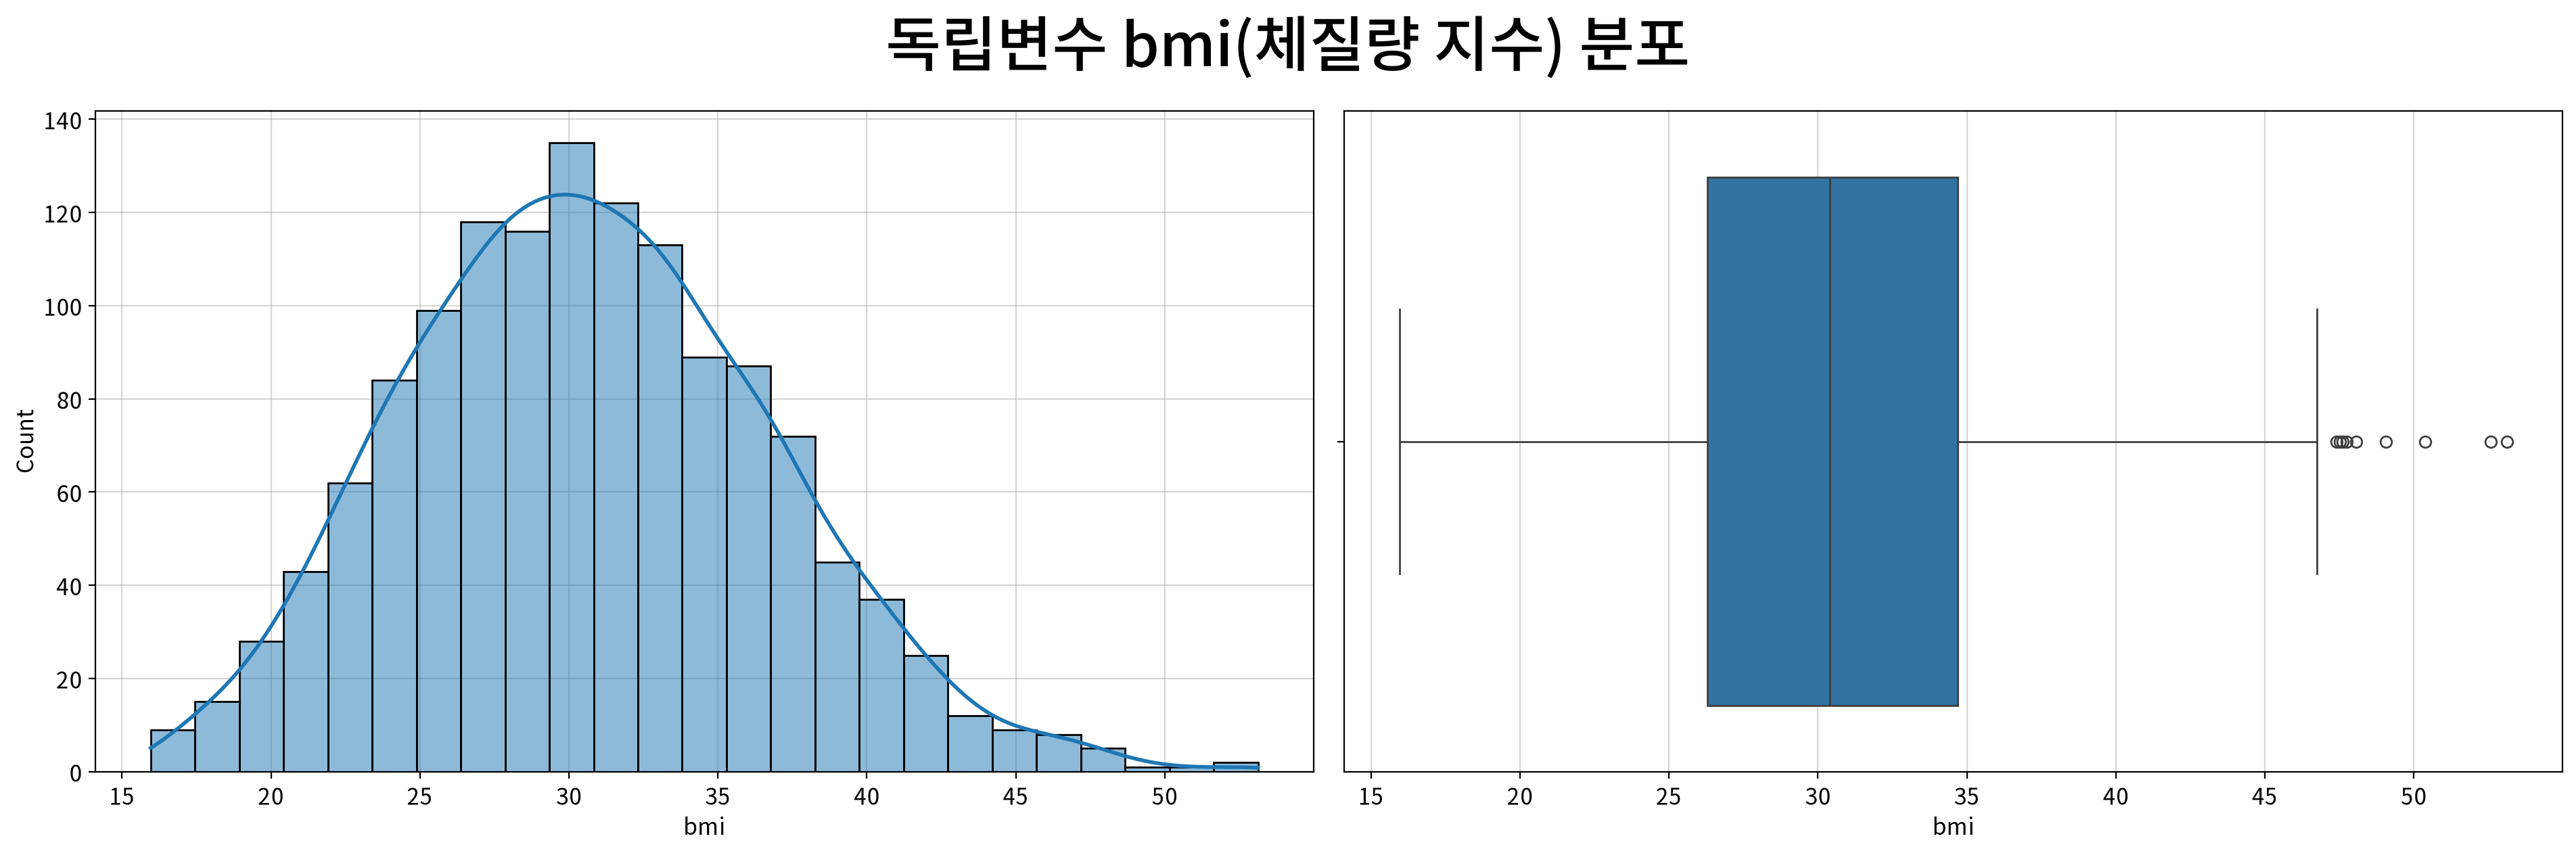

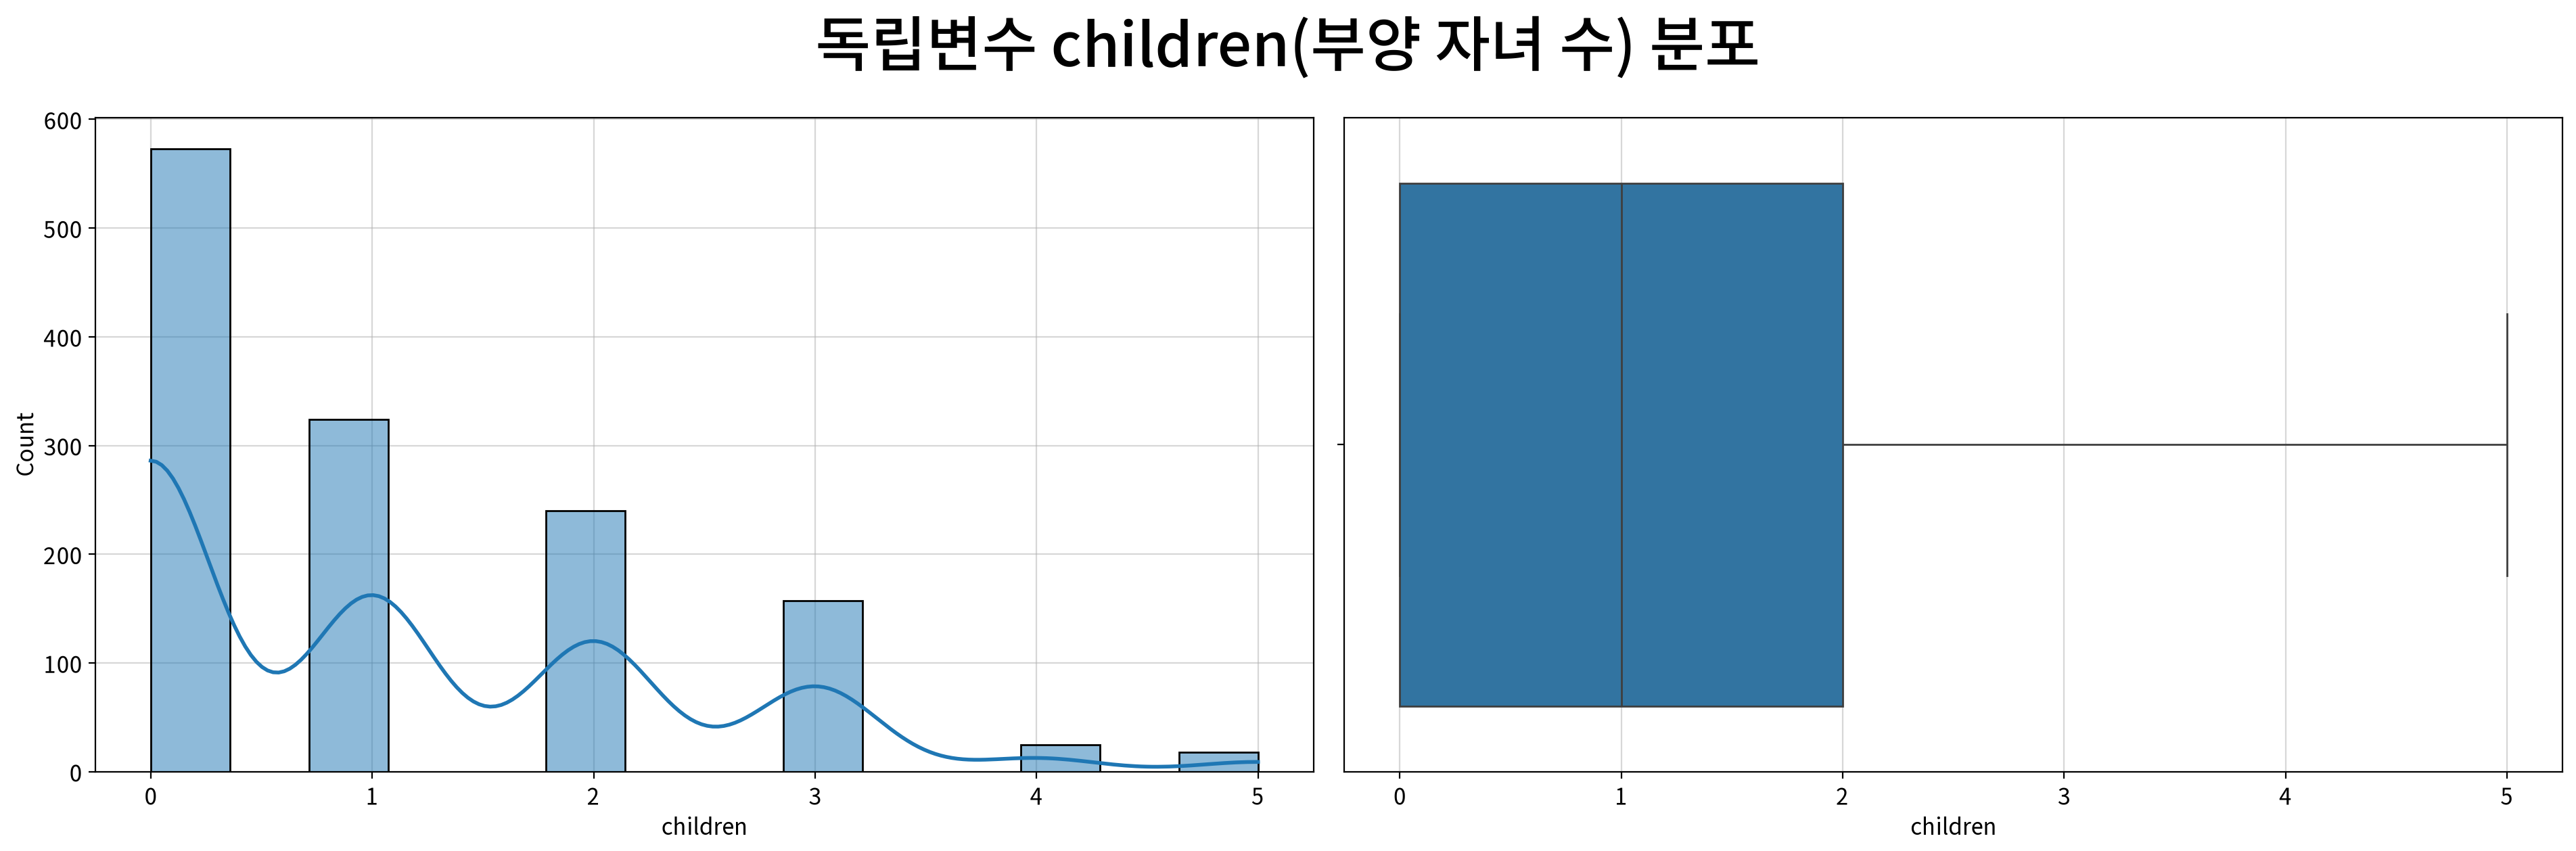

,children
count,1337.000
mean,1.096
std,1.206
min,0.000
25%,0.000
50%,1.000
75%,2.000
max,5.000
rel_diff,0.096
rdiff_flag,similar


In [24]:
for f in continuous_cols: 
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640, 
                           title=f"독립변수 {f}({column_means[f]}) 분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

display(desc[desc.index == f].T)

### 2. 명목형 독립 변수 

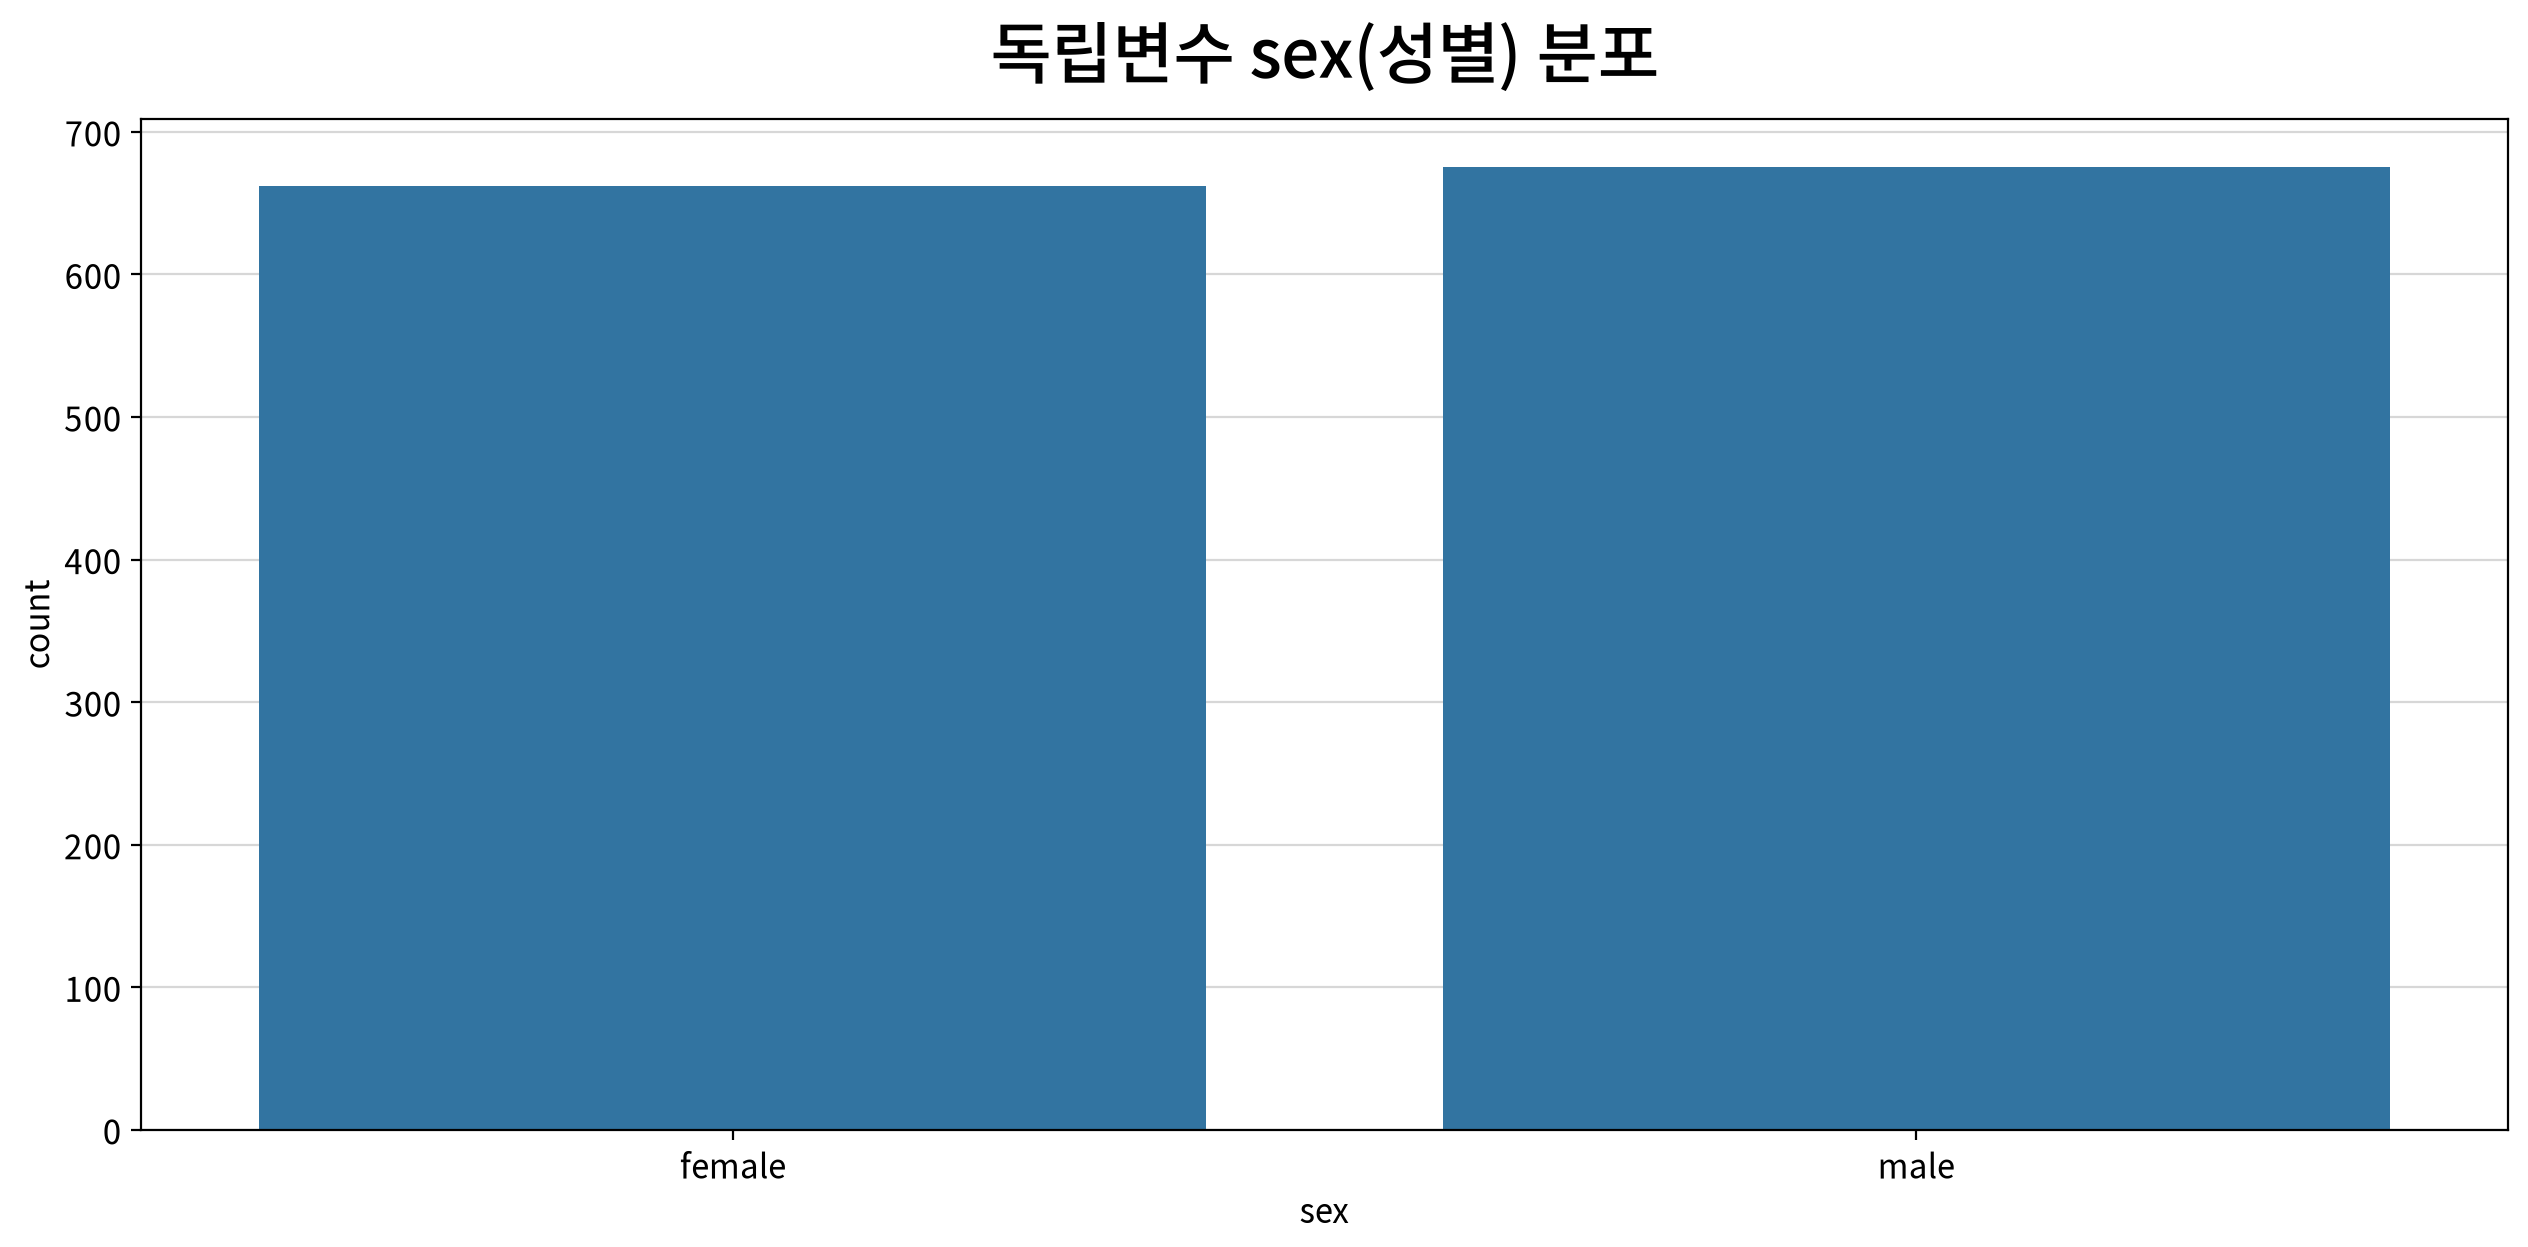

,count,unique,top,freq
sex,1337,2,male,675


,빈도,비율
sex,,
male,675,0.505
female,662,0.495


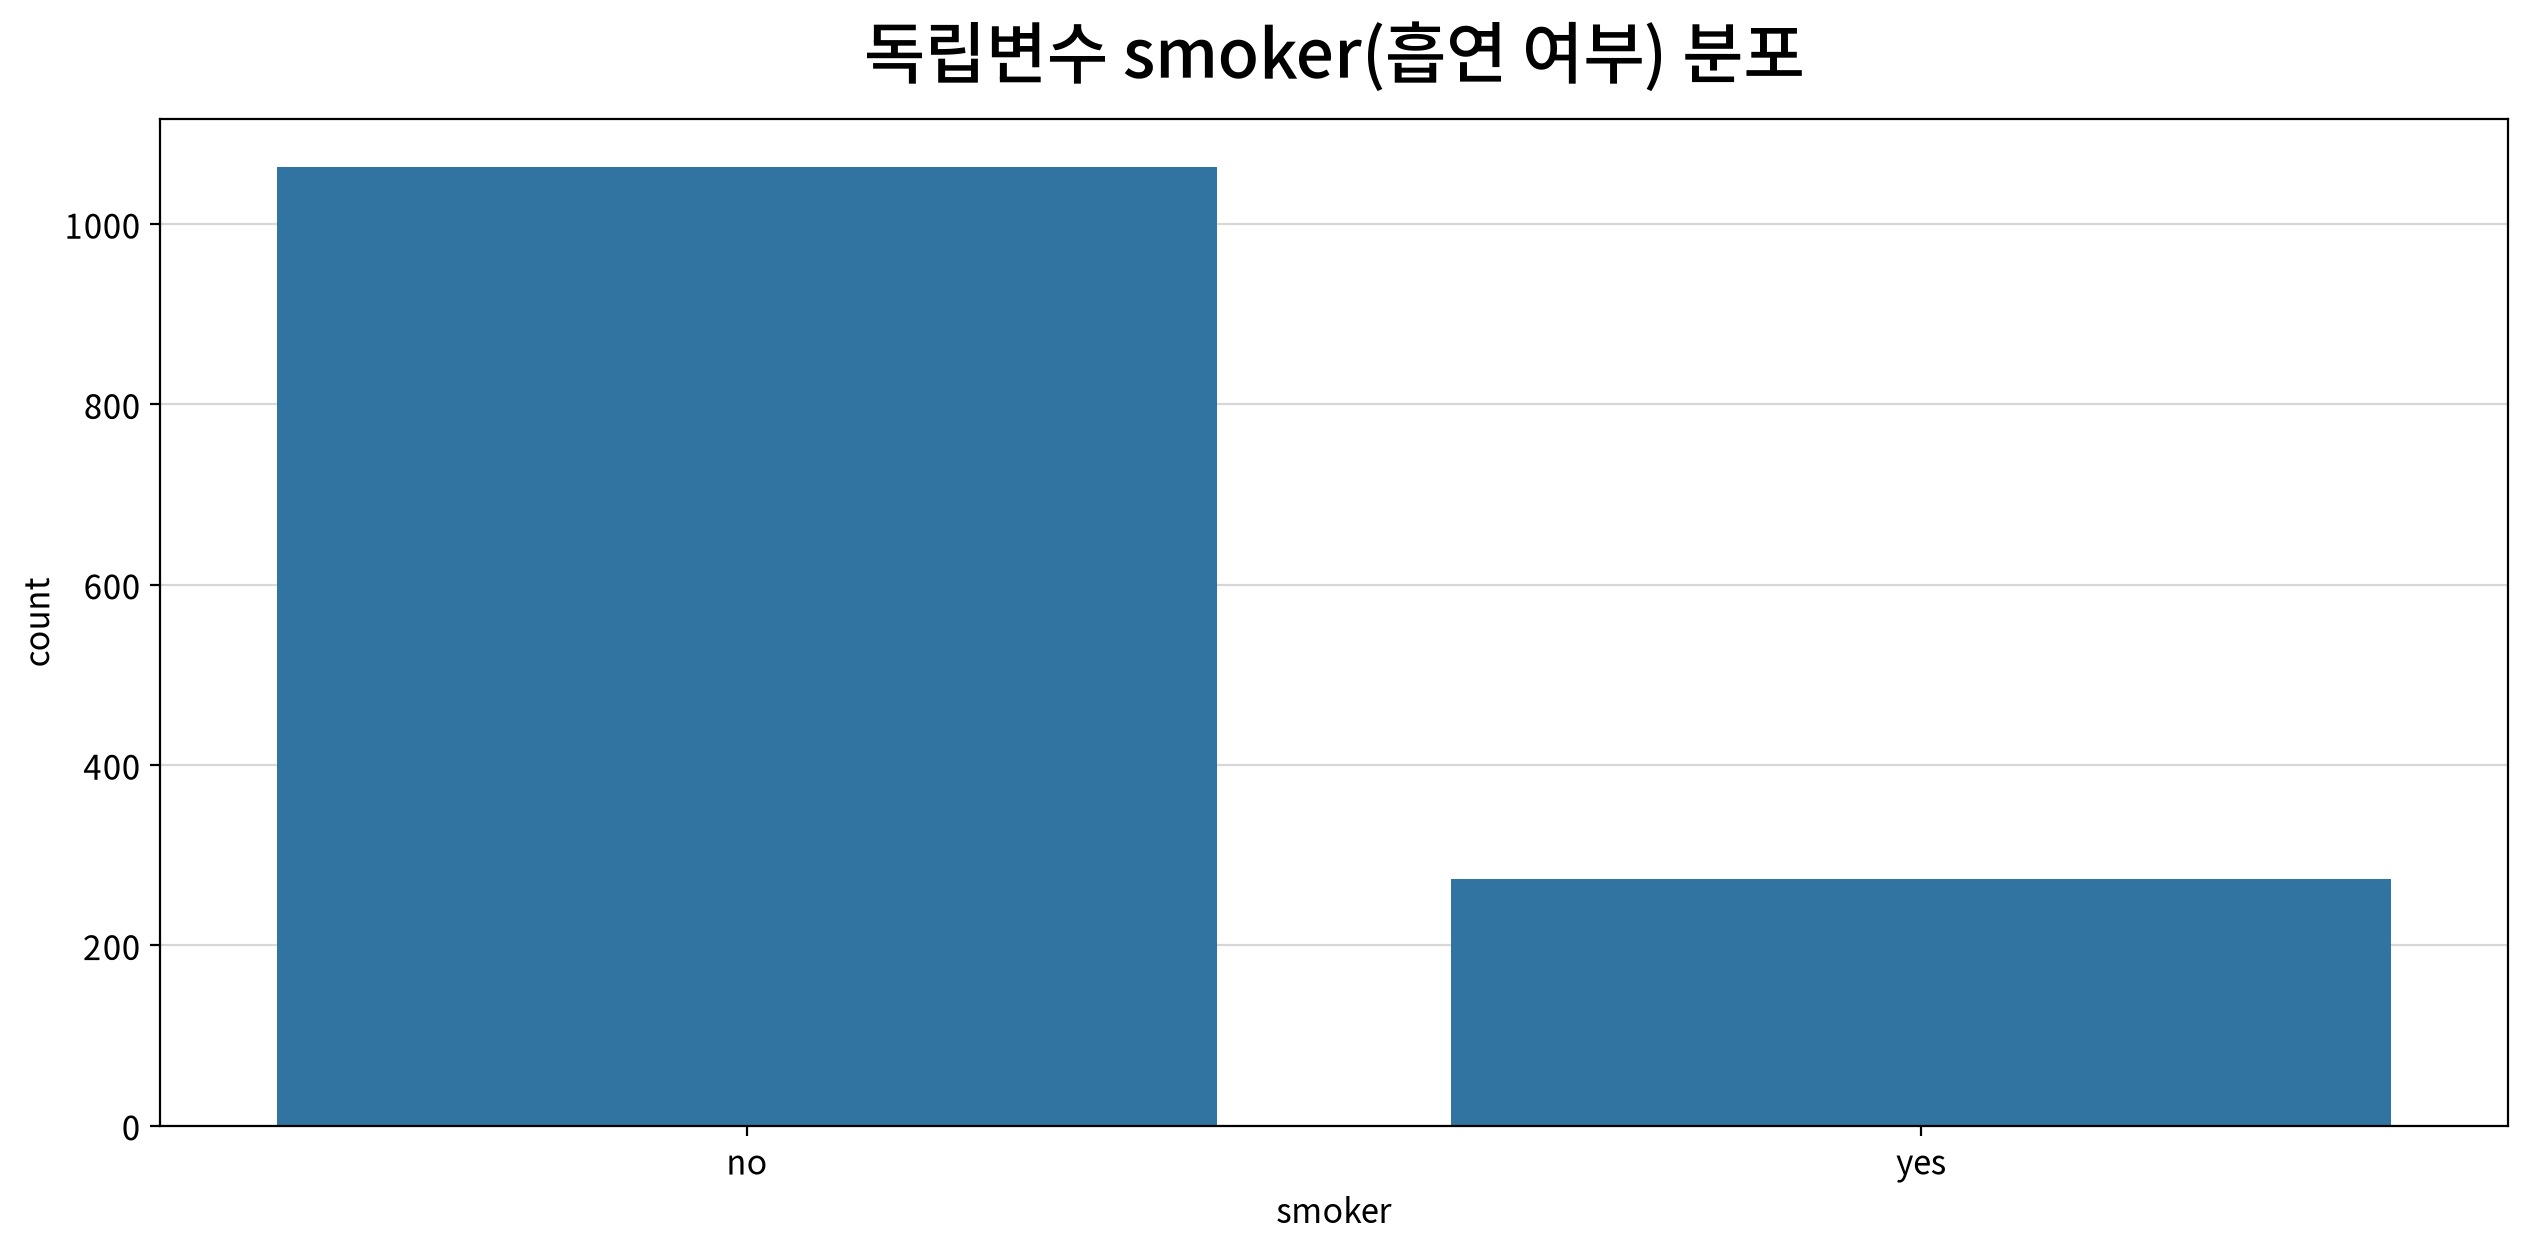

,count,unique,top,freq
smoker,1337,2,no,1063


,빈도,비율
smoker,,
no,1063,0.795
yes,274,0.205


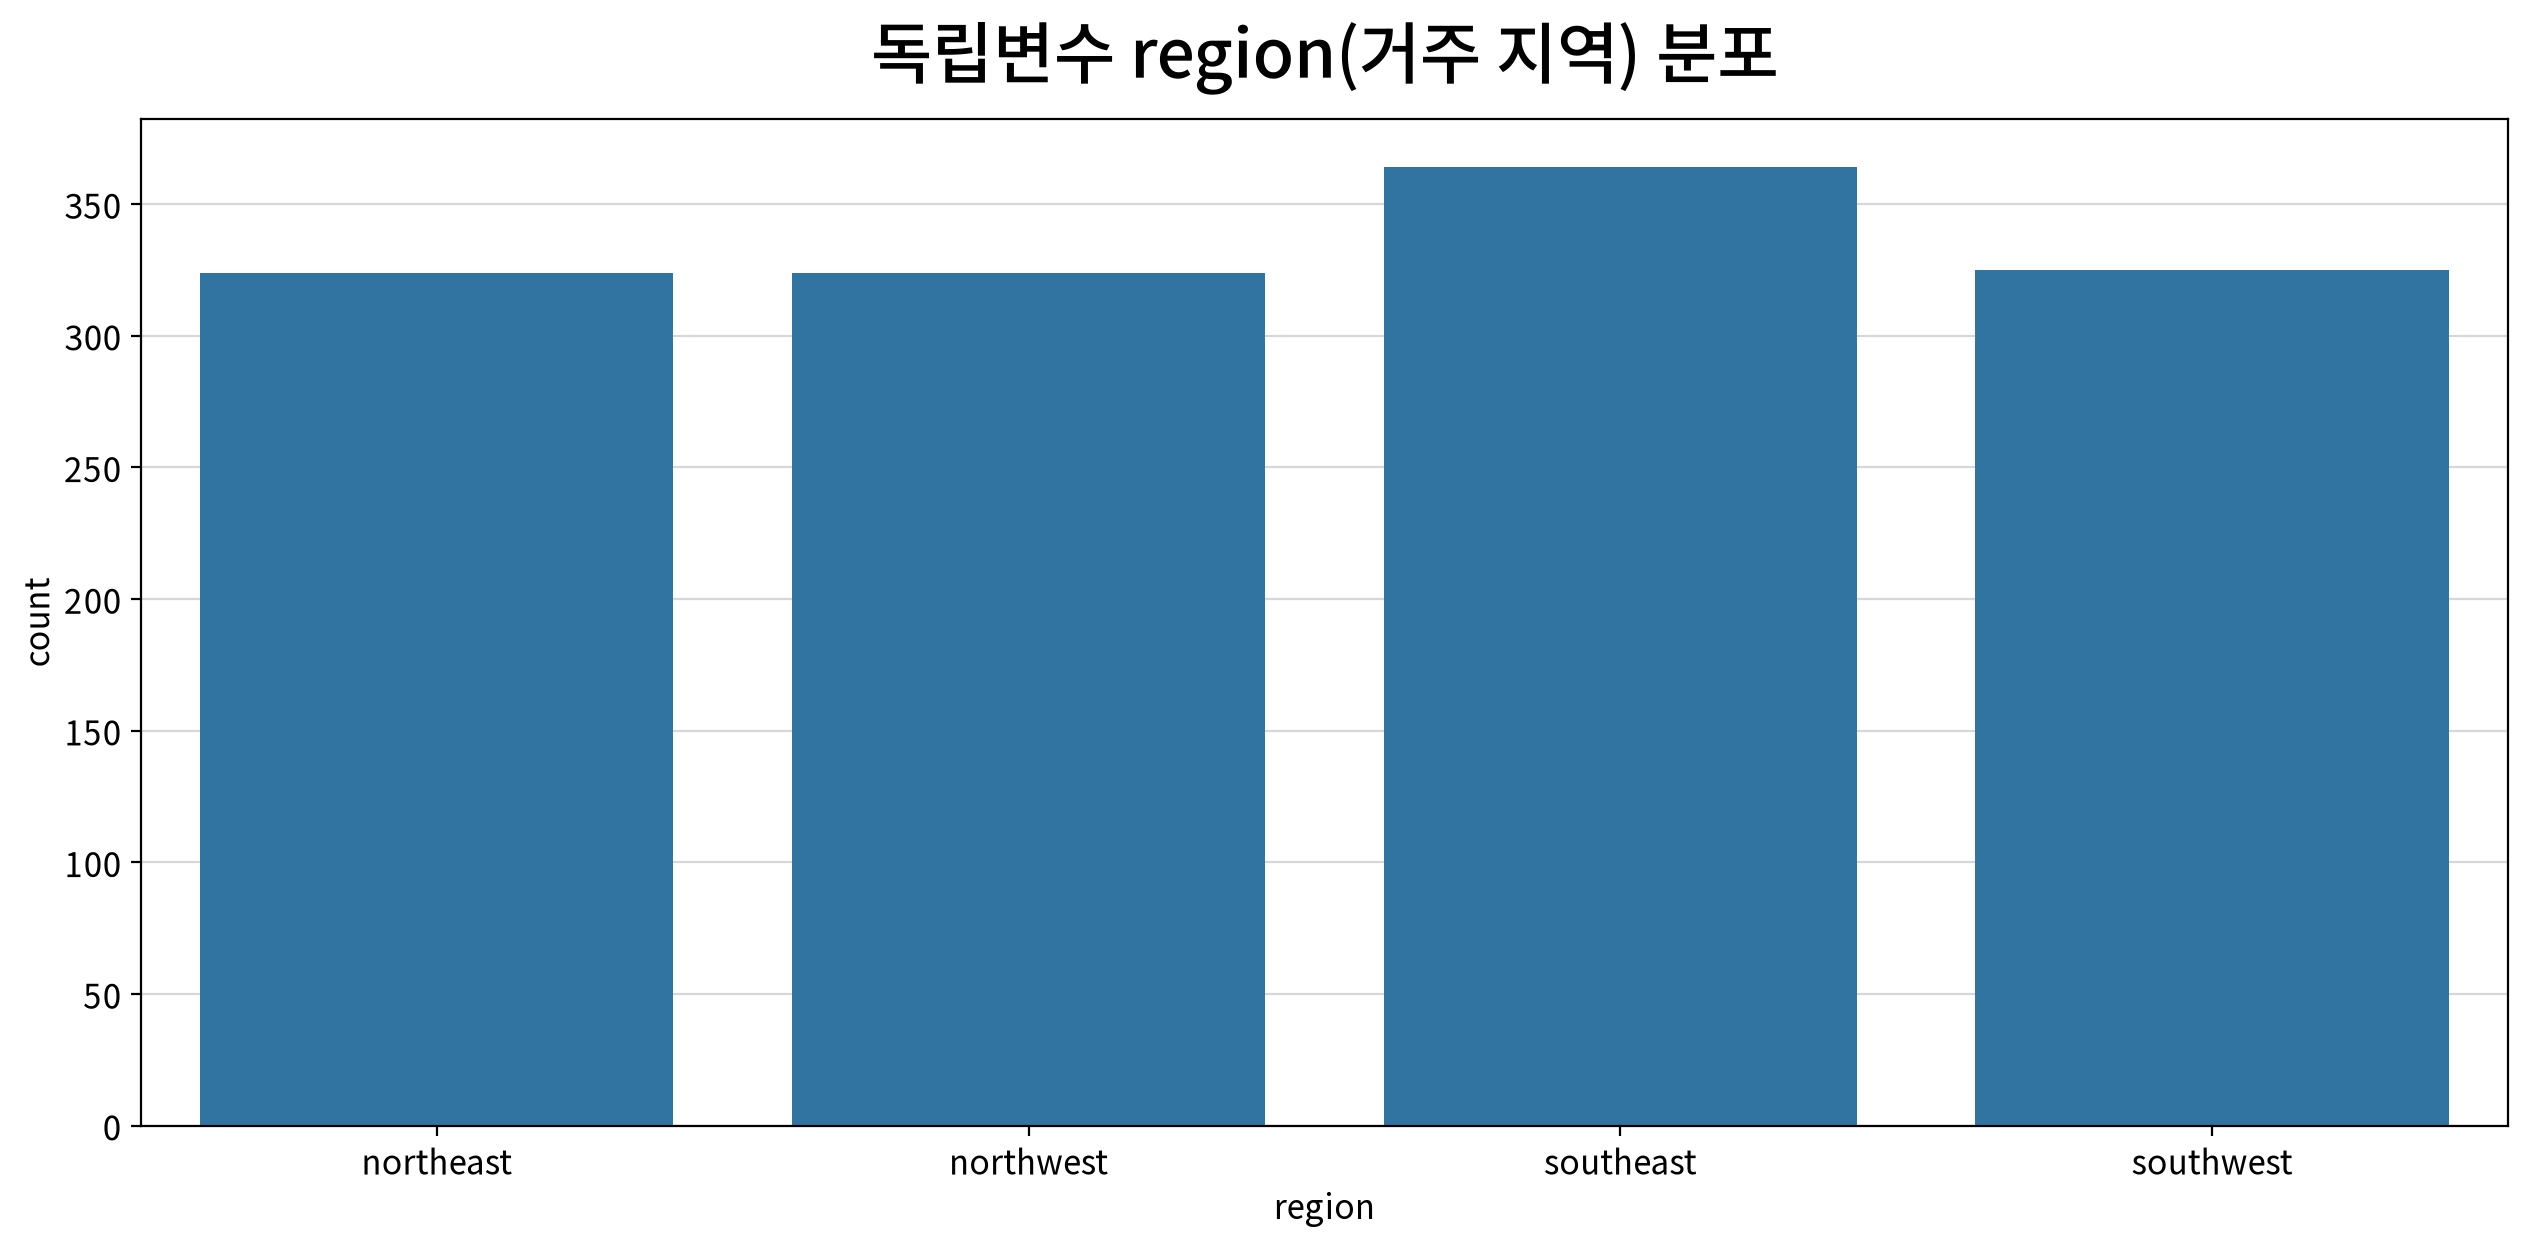

,count,unique,top,freq
region,1337,4,southeast,364


,빈도,비율
region,,
southeast,364,0.272
southwest,325,0.243
northeast,324,0.242
northwest,324,0.242


In [25]:
for n in nominal_cols:
    # 명목형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, title=f"독립변수 {n}({column_means[n]}) 분포")
    
    # 명목형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df[n].value_counts().rename("빈도").to_frame()
    # value_counts(normalize=sTrue)
    # --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산 
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)